# Data Analysis for all combinations of n-substituents [6]Helicenes
This notebook provides a structured workflow to obtain all the predictions for halogenated [6]Helicenes from 1 up to 6 substituents, and up to 16 due to the computational cost will just predict 100 random molecules for each substituents.

# Check for GPU usage

In [1]:
import tensorflow as tf
# Check TensorFlow version for compatibility
print("TensorFlow version:", tf.__version__)
# List available GPUs for GPU acceleration
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("GPUs:", physical_devices)
    try:
        # Enable dynamic memory growth (best practice to avoid GPU memory errors)
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except Exception as e:
        pass
else:
    print("No GPU found, using CPU.")

TensorFlow version: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load data, our models and import libraries
Load x_data and y_data as well as OHE variables and stats like mean and std Rmin values from Load_manipulate notebook, as well as our model and it's upper and lower models aplications for obtaining the uncertainty intervals.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the CSV file
data_combined = pd.read_csv('OHE_data.csv')

# Separate x_data and y_data
x_data = data_combined.iloc[:, :-1].values  # All columns except the last one
y_data = data_combined['target'].values    # The last column

# Load trained and tested x_data and y_data
x_train = pd.read_csv('x_train.csv')
y_train = pd.read_csv('y_train.csv')
x_test = pd.read_csv('x_test.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


# Helicene parameters
n_atom_types = 5          # e.g., 5 atom types (H, F, Cl, Br, I)
n_pos = 16                # number of possible positions (16)
n_features = n_atom_types * n_pos  # total one-hot features

# Load Rmin_abs_mean and Rmin_abs_std from the CSV file
stats = pd.read_csv('Rmin_stats.csv')
Rmin_abs_mean = stats['Rmin_abs_mean'].values[0]
Rmin_abs_std = stats['Rmin_abs_std'].values[0]

# Load the pre-trained model

model_path = './CV_Models/Rmin_model_CV'
best_model = tf.keras.models.load_model(model_path)

print("Model loaded successfully!")

# Load the lower and upper quantile models
model_lower =  tf.keras.models.load_model('Rmin_model_lower.h5', compile=False)
model_upper =  tf.keras.models.load_model('Rmin_model_upper.h5', compile=False)

print("Quantile models loaded successfully!")


x_train shape: (946, 80)
y_train shape: (946,)
x_test shape: (237, 80)
y_test shape: (237,)
Model loaded successfully!
Quantile models loaded successfully!


# Data analysis from mono to hexa-halogenated [6]Helicenes

In [3]:
# Import combinatory library to generate combinations
from itertools import combinations, product, permutations

In [4]:
# Define the positions in the [6]Helicene molecule
positions = list(range(1, 17))  # Posiciones 1 a 16

# Define the halogens
halogens = ['F', 'Cl', 'Br', 'I']

In [5]:
from time import perf_counter

# ----------------------------
# Configuration
halogen_to_index = {'H': 0, 'F': 1, 'Cl': 2, 'Br': 3, 'I': 4}
BATCH_SIZE = 4096
# ----------------------------

# Fast one-hot encoder
def encode_batch(molecules):
    one_hot = np.zeros((len(molecules), n_pos * n_atom_types), dtype=np.float32)
    for i, mol in enumerate(molecules):
        for j, atom in enumerate(mol):
            idx = halogen_to_index[atom]
            one_hot[i, j * n_atom_types + idx] = 1.0
    return one_hot

# Molecule generator with symmetry filtering
def generate_unique_molecules(n_subs):
    visited = set()
    for pos_comb in combinations(positions, n_subs):
        for hal_comb in product(halogens, repeat=n_subs):
            mol = ['H'] * n_pos
            for pos, hal in zip(pos_comb, hal_comb):
                mol[pos - 1] = hal
            mol_tuple = tuple(mol)
            mol_rev = tuple(mol[::-1])
            if mol_rev in visited:
                continue
            visited.add(mol_tuple)
            yield mol

# Main predictor
def predict_rmin_substituted(n_subs, model, mean, std):
    print(f"\n Predicting {n_subs}-halogenated molecules...")
    start_total = perf_counter()

    predictions = []
    batch_raw = []
    batch_id = 0

    molecule_generator = generate_unique_molecules(n_subs)

    for mol in molecule_generator:
        batch_raw.append(mol)

        if len(batch_raw) == BATCH_SIZE:
            encoded = encode_batch(batch_raw)

            with tf.device('/GPU:0'):
                pred_norm = model.predict(encoded, verbose=0)

            pred = pred_norm * std + mean
            predictions.extend([(mol, val[0]) for mol, val in zip(batch_raw, pred)])

            if batch_id % 10 == 0:
                print(f"Batch {batch_id}: processed {len(predictions)} molecules")
            batch_raw.clear()
            batch_id += 1

    # Process leftover molecules
    if batch_raw:
        encoded = encode_batch(batch_raw)
        with tf.device('/GPU:0'):
            pred_norm = model.predict(encoded, verbose=0)
        pred = pred_norm * std + mean
        predictions.extend([(mol, val[0]) for mol, val in zip(batch_raw, pred)])
        batch_raw.clear()

    # Sort by predicted Rmin
    predictions.sort(key=lambda x: x[1], reverse=False)

    # Summary
    print(f"\nTop 10 {n_subs}-halogenated molecules:")
    for i, (mol, rmin) in enumerate(predictions[:10]):
        print(f"{i+1:2d}. Rmin = {rmin:.2f} → {mol}")

    print(f"\n Finished: {len(predictions)} molecules in {perf_counter() - start_total:.2f} s")

    return predictions


# Data analysis for Mono-halogenated [6]Helicene

In [6]:
# Predict Rmin for mono-halogenated molecules
mono_predictions = predict_rmin_substituted(
    n_subs=1,
    model=best_model,
    mean=Rmin_abs_mean,
    std=Rmin_abs_std,
)
# Mean Rmin value
mean_rmin = np.mean([pred[1] for pred in mono_predictions])
print(f"Mean Rmin value for all mono-halogenated molecules: {mean_rmin:.2f}")



 Predicting 1-halogenated molecules...

Top 10 1-halogenated molecules:
 1. Rmin = -646.31 → ['H', 'H', 'I', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
 2. Rmin = -625.35 → ['H', 'H', 'Br', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
 3. Rmin = -601.09 → ['H', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
 4. Rmin = -568.17 → ['H', 'H', 'H', 'H', 'I', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
 5. Rmin = -547.77 → ['H', 'H', 'H', 'H', 'Br', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
 6. Rmin = -537.61 → ['H', 'H', 'H', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
 7. Rmin = -522.97 → ['H', 'H', 'H', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
 8. Rmin = -515.88 → ['H', 'H', 'H', 'H', 'H', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
 9. Rmin = -507.52 → ['H', 'H', 'H', 'H', 'H', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
10. 

# ΔR_min by Position for Monohalogenated [6]Helicene

1/1 [==============================] - 0s 117ms/step
Rmin for all-H molecule: -520.45


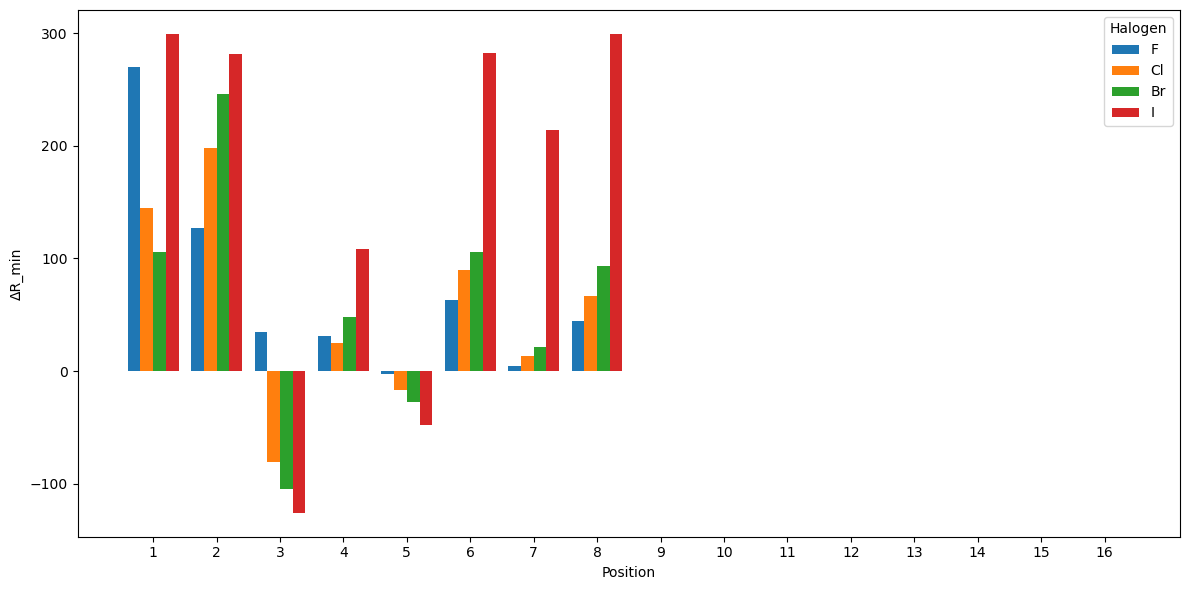

In [7]:
# Define the positions in the [6]Helicene molecule as an array
positions_array = np.arange(1, 17)  # Positions 1 to 16

def encode_molecule(substitutions, n_pos=16, n_atom_types=5):
    one_hot = np.zeros((1, n_pos * n_atom_types), dtype=np.float32)
    for i, atom in enumerate(substitutions):
        idx = halogen_to_index[atom]
        one_hot[0, i * n_atom_types + idx] = 1.0
    return one_hot

# Step 1: Get Rmin for the all-H molecule
base_subs = ['H'] * 16
encoded_H = encode_molecule(base_subs, n_pos=16, n_atom_types=5)
rmin_H = float(best_model.predict(encoded_H)[0])

# Denormalize Rmin for the all-H molecule
rmin_H = rmin_H * Rmin_abs_std + Rmin_abs_mean
print(f"Rmin for all-H molecule: {rmin_H:.2f}")

# Step 2: Build ΔRmin by position per halogen from existing mono_predictions
delta_rmin = {hal: [0.0] * 16 for hal in halogens}

for molecule, rmin in mono_predictions:
    # Find the substituted position and the halogen used
    for idx, atom in enumerate(molecule):
        if atom in halogens:
            pos = idx  # 0-based index
            hal = atom
            break
    delta = rmin - rmin_H
    delta_rmin[hal][pos] = delta

# Step 3: Plotting
bar_width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(12, 6))

for i, hal in enumerate(halogens):
    pos_shifted = positions_array + offsets[i] * bar_width
    ax.bar(pos_shifted, delta_rmin[hal], width=bar_width, label=hal)

ax.set_xticks(positions_array)
ax.set_xticklabels(positions_array)
ax.set_xlabel('Position')
ax.set_ylabel('ΔR_min')
ax.legend(title='Halogen')
plt.tight_layout()
plt.show()


# Data analysis for Di-halogenated [6]Helicene

In [8]:
BATCH_SIZE = 512
di_predictions = predict_rmin_substituted(
    n_subs=2,
    model=best_model,
    mean=Rmin_abs_mean,
    std=Rmin_abs_std
)
# Mean Rmin value
mean_rmin = np.mean([pred[1] for pred in di_predictions])
print(f"Mean Rmin value for all di-halogenated molecules: {mean_rmin:.2f}")


 Predicting 2-halogenated molecules...
Batch 0: processed 512 molecules

Top 10 2-halogenated molecules:
 1. Rmin = -749.04 → ['H', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'I', 'H', 'H']
 2. Rmin = -747.54 → ['H', 'H', 'Br', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'H']
 3. Rmin = -746.76 → ['H', 'H', 'Br', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'I', 'H', 'H']
 4. Rmin = -743.15 → ['H', 'H', 'I', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'I', 'H', 'H']
 5. Rmin = -727.00 → ['H', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'H']
 6. Rmin = -684.19 → ['H', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Cl', 'H', 'H']
 7. Rmin = -667.76 → ['H', 'H', 'I', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'H', 'H', 'H']
 8. Rmin = -667.30 → ['H', 'H', 'I', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Cl', 'H', 'H', 'H', 'H']
 9. Rmin = -664.20 → ['H', 'H', 'I', 'H', 'H', 'H', 'H', 'H', 'H', '

# Predictions with Rmin lower than -550
This conditional is made to then visualize in a plot the positions tendecy of dihalogenated molecules. Batch is used just to make it quick since we have done to predictions before of the same thing for the sake of the analysis for a better and quicker predicting function.

In [9]:
# Filter di_predictions for Rmin <= -500
good_candidates = [(mol, rmin) for mol, rmin in di_predictions if rmin <= -500]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)

print(f"\nTotal molecules with Rmin <= -500: {len(good_candidates)}")

# Filter top 1000 di_predictions
good_candidates = di_predictions[:1000]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)



Total molecules with Rmin <= -500: 153


# Location of Halogens in Dihalogenated [6]Helicenes

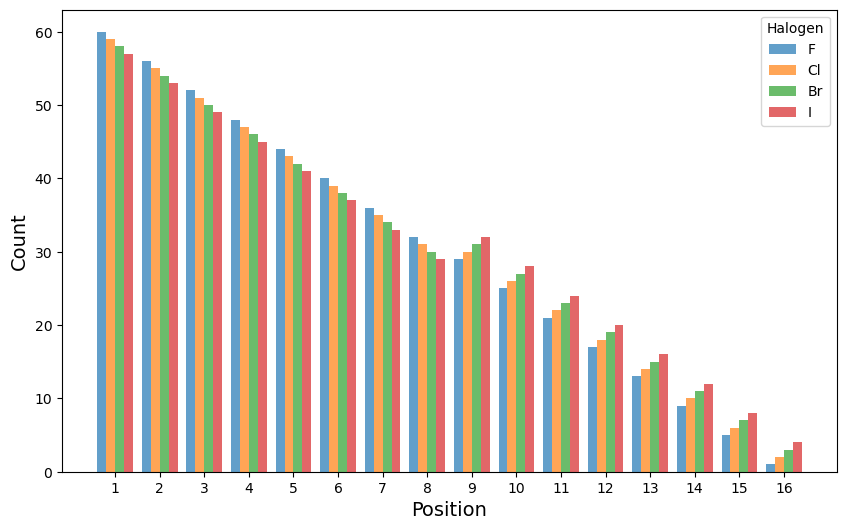

In [10]:
# Count the occurrences of each halogen at each position
halogen_counts = {halogen: [0] * len(positions) for halogen in halogens}
for molecule, _ in good_candidates:  # Unpack the tuple
    for pos, atom in enumerate(molecule):
        if atom in halogens:
            halogen_counts[atom][pos] += 1

# Plot the results
plt.figure(figsize=(10, 6))
bar_width = 0.2
offsets = [-1.5 * bar_width, -0.5 * bar_width, 0.5 * bar_width, 1.5 * bar_width]  # For 4 halogens

for i, (halogen, counts) in enumerate(halogen_counts.items()):
    plt.bar(
        [pos + offsets[i] for pos in range(len(positions))],
        counts,
        width=bar_width,
        label=halogen,
        alpha=0.7
    )

plt.xlabel("Position", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(range(len(positions)), [str(p) for p in positions])
plt.legend(title="Halogen")
plt.grid(False)
plt.show()

# ΔR_min by Position for Dihalogenated [6]Helicene

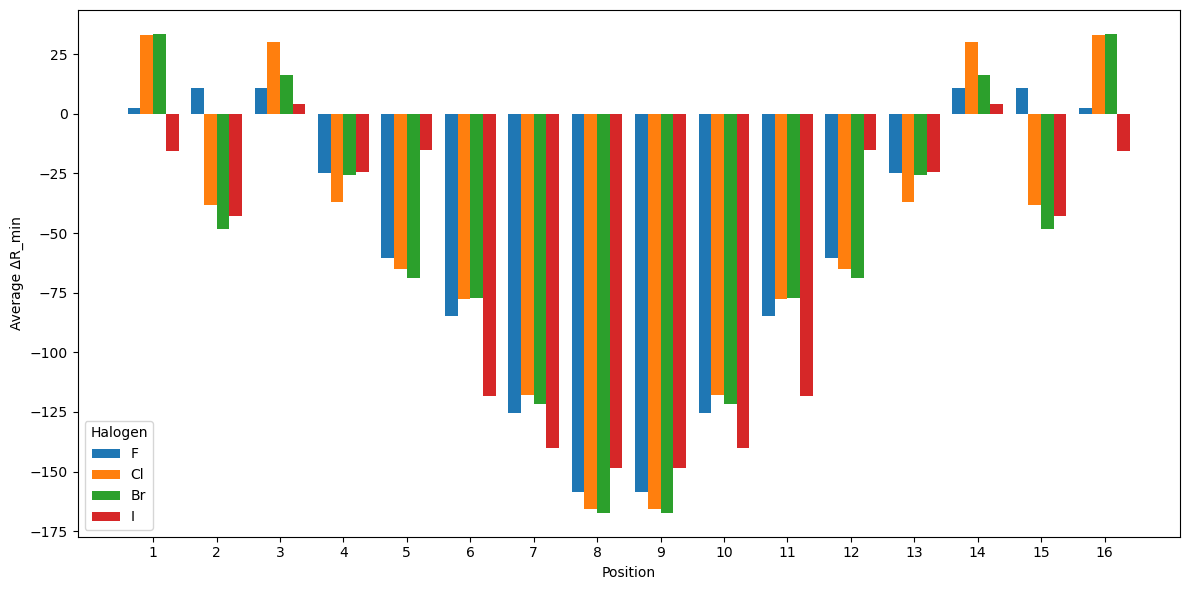

In [11]:
# Reuse predictions
mono_rmin = {tuple(molecule): rmin for molecule, rmin in mono_predictions}
di_rmin = {tuple(molecule): rmin for molecule, rmin in di_predictions}

# Initialize accumulators
delta_rmin_dihalogenated = {hal: [0.0] * 16 for hal in halogens}
count_deltas = {hal: [0] * 16 for hal in halogens}

# Step 1: Accumulate ΔR_min from dihalogenated molecules
for molecule, rmin_di in di_rmin.items():
    halogens_in_molecule = [(pos, atom) for pos, atom in enumerate(molecule) if atom in halogens]
    if len(halogens_in_molecule) != 2:
        continue

    (pos_i, hal_i), (pos_j, hal_j) = halogens_in_molecule

    mono_i = list(molecule)
    mono_i[pos_j] = 'H'
    mono_j = list(molecule)
    mono_j[pos_i] = 'H'

    rmin_mono_i = mono_rmin.get(tuple(mono_i), 0)
    rmin_mono_j = mono_rmin.get(tuple(mono_j), 0)

    delta_i = rmin_di - rmin_mono_i
    delta_j = rmin_di - rmin_mono_j

    delta_rmin_dihalogenated[hal_i][pos_i] += delta_i
    delta_rmin_dihalogenated[hal_j][pos_j] += delta_j
    count_deltas[hal_i][pos_i] += 1
    count_deltas[hal_j][pos_j] += 1

# Step 2: Compute symmetric-averaged ΔR_min
for hal in halogens:
    for i in range(8):  # 0 to 7
        j = 15 - i  # Mirror position
        # Combine values and counts
        total_delta = delta_rmin_dihalogenated[hal][i] + delta_rmin_dihalogenated[hal][j]
        total_count = count_deltas[hal][i] + count_deltas[hal][j]
        # Avoid division by zero
        avg = total_delta / total_count if total_count > 0 else 0.0
        # Assign symmetric average to both positions
        delta_rmin_dihalogenated[hal][i] = avg
        delta_rmin_dihalogenated[hal][j] = avg

# Step 3: Plotting
positions_array = np.arange(16)
bar_width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(12, 6))

for i, hal in enumerate(halogens):
    pos_shifted = positions_array + offsets[i] * bar_width
    ax.bar(pos_shifted, delta_rmin_dihalogenated[hal], width=bar_width, label=hal)

ax.set_xticks(positions_array)
ax.set_xticklabels(positions_array + 1)
ax.set_xlabel('Position')
ax.set_ylabel('Average ΔR_min')
ax.legend(title='Halogen')
plt.tight_layout()
plt.show()


# Data analysis for Tri-halogenated [6]Helicene

In [12]:
BATCH_SIZE = 1024
tri_predictions = predict_rmin_substituted(
    n_subs=3,
    model=best_model,
    mean=Rmin_abs_mean,
    std=Rmin_abs_std
)
#Mean Rmin value
mean_rmin = np.mean([pred[1] for pred in tri_predictions])
print(f"Mean Rmin value for all tri-halogenated molecules: {mean_rmin:.2f}")


 Predicting 3-halogenated molecules...
Batch 0: processed 1024 molecules
Batch 10: processed 11264 molecules

Top 10 3-halogenated molecules:
 1. Rmin = -747.16 → ['H', 'H', 'I', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'I', 'H', 'H']
 2. Rmin = -746.84 → ['H', 'H', 'Br', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'I', 'H', 'H']
 3. Rmin = -745.71 → ['H', 'H', 'I', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'H']
 4. Rmin = -742.65 → ['H', 'H', 'I', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'I', 'H', 'H']
 5. Rmin = -741.57 → ['H', 'H', 'Cl', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'I', 'H', 'H']
 6. Rmin = -741.01 → ['H', 'H', 'Br', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'H']
 7. Rmin = -739.13 → ['H', 'H', 'I', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'H']
 8. Rmin = -739.10 → ['H', 'H', 'I', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'Cl', 'H', 'H']
 9. Rmin = -737.25 → ['H', 'H', 

# Predictions with Rmin lower than -600

In [13]:
# Filter tri_predictions for Rmin <= 600
good_candidates = [(mol, rmin) for mol, rmin in tri_predictions if rmin <= -600]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)

print(f"\nTotal molecules with Rmin <= -600: {len(good_candidates)}")

# Filter top 1000 tri_predictions
good_candidates = tri_predictions[:1000]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)


Total molecules with Rmin <= -600: 235


# Location of Halogens in Trihalogenated [6]Helicenes

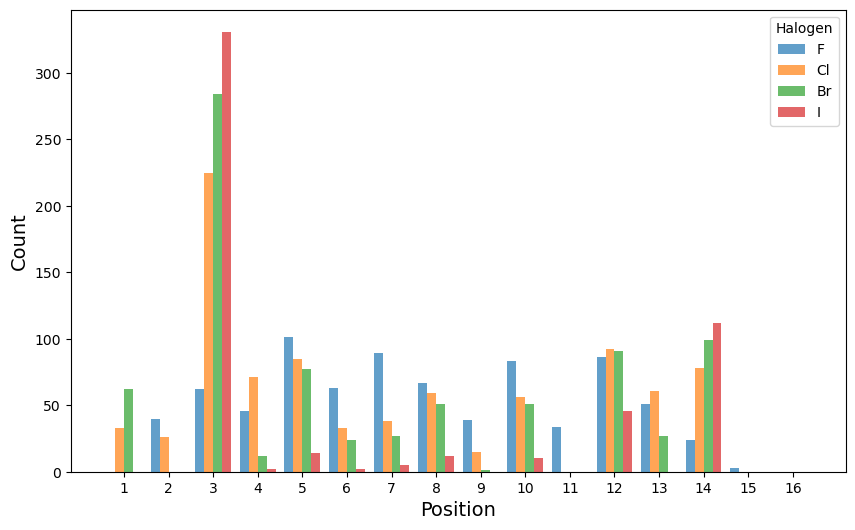

In [14]:
# Count the occurrences of each halogen at each position
halogen_counts = {halogen: [0] * len(positions) for halogen in halogens}
for molecule, _ in good_candidates:  # Unpack the tuple
    for pos, atom in enumerate(molecule):
        if atom in halogens:
            halogen_counts[atom][pos] += 1

# Plot the results
plt.figure(figsize=(10, 6))
bar_width = 0.2
offsets = [-1.5 * bar_width, -0.5 * bar_width, 0.5 * bar_width, 1.5 * bar_width]  # For 4 halogens

for i, (halogen, counts) in enumerate(halogen_counts.items()):
    plt.bar(
        [pos + offsets[i] for pos in range(len(positions))],
        counts,
        width=bar_width,
        label=halogen,
        alpha=0.7
    )

plt.xlabel("Position", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(range(len(positions)), [str(p) for p in positions])
plt.legend(title="Halogen")
plt.grid(False)
plt.show()

# ΔR_min by Position for Trihalogenated [6]Helicene (vs Dihalogenated)

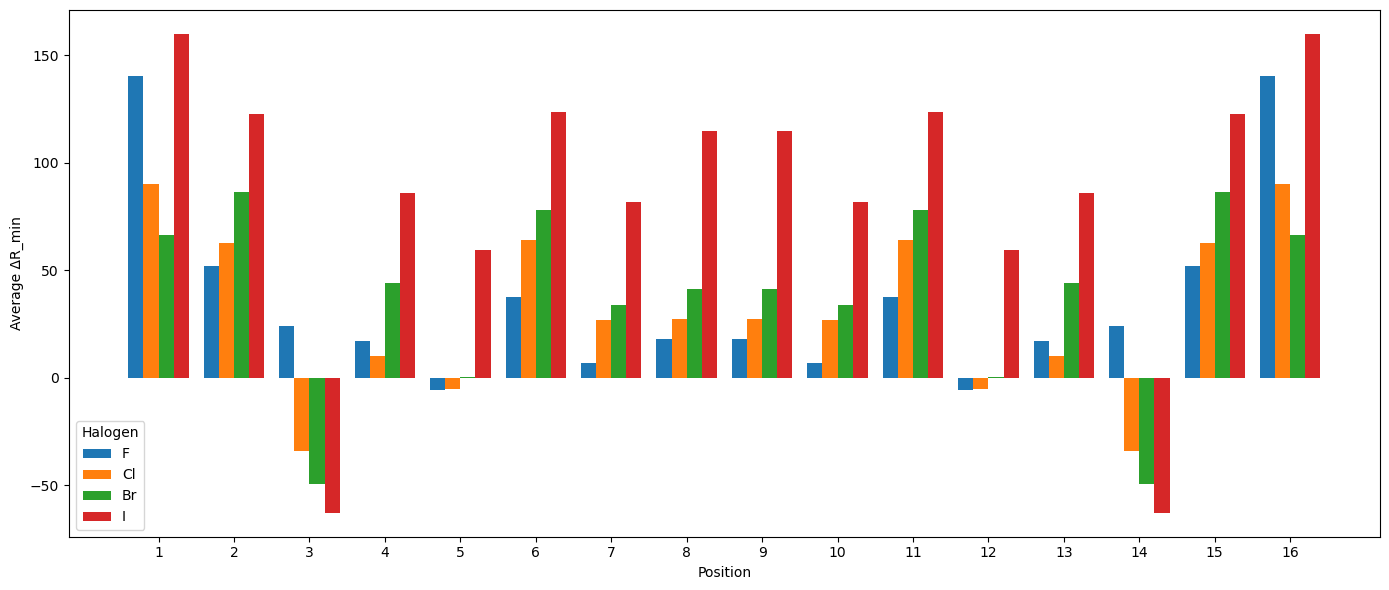

In [15]:
# Step 0: Prepare dictionaries from previous predictions
tri_rmin = {tuple(molecule): rmin for molecule, rmin in tri_predictions}

# Initialize accumulators
delta_rmin_trihalogenated = {hal: [0.0] * 16 for hal in halogens}
count_deltas = {hal: [0] * 16 for hal in halogens}

# Step 1: Accumulate ΔR_min from trihalogenated vs dihalogenated
for molecule, rmin_tri in tri_rmin.items():
    # Find halogen positions
    halogens_in_molecule = [(pos, atom) for pos, atom in enumerate(molecule) if atom in halogens]
    if len(halogens_in_molecule) != 3:
        continue  # Skip invalid entries

    # For each of the three dihalogenated variants (remove one halogen)
    for idx in range(3):
        (pos_removed, hal_removed) = halogens_in_molecule[idx]
        di_molecule = list(molecule)
        di_molecule[pos_removed] = 'H'

        rmin_di = di_rmin.get(tuple(di_molecule), None)
        if rmin_di is None:
            continue  # Skip if corresponding dihalogenated molecule is missing

        delta = rmin_tri - rmin_di
        delta_rmin_trihalogenated[hal_removed][pos_removed] += delta
        count_deltas[hal_removed][pos_removed] += 1

# Step 2: Enforce symmetry (mirror-averaged values)
for hal in halogens:
    for i in range(8):
        j = 15 - i  # Mirror position
        total_delta = delta_rmin_trihalogenated[hal][i] + delta_rmin_trihalogenated[hal][j]
        total_count = count_deltas[hal][i] + count_deltas[hal][j]
        avg = total_delta / total_count if total_count > 0 else 0.0
        delta_rmin_trihalogenated[hal][i] = avg
        delta_rmin_trihalogenated[hal][j] = avg

# Step 3: Plotting
positions_array = np.arange(16)
bar_width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(14, 6))

for i, hal in enumerate(halogens):
    pos_shifted = positions_array + offsets[i] * bar_width
    ax.bar(pos_shifted, delta_rmin_trihalogenated[hal], width=bar_width, label=hal)

ax.set_xticks(positions_array)
ax.set_xticklabels(positions_array + 1)
ax.set_xlabel('Position')
ax.set_ylabel('Average ΔR_min')
ax.legend(title='Halogen')
plt.tight_layout()
plt.show()


# Data analysis for tetra-halogenated [6]Helicenes

In [16]:
BATCH_SIZE = 4096
tetra_predictions = predict_rmin_substituted(
    n_subs=4,
    model=best_model,
    mean=Rmin_abs_mean,
    std=Rmin_abs_std
)
#Mean Rmin value
mean_rmin = np.mean([pred[1] for pred in tetra_predictions])
print(f"Mean Rmin value for all tetra-halogenated molecules: {mean_rmin:.2f}")


 Predicting 4-halogenated molecules...
Batch 0: processed 4096 molecules
Batch 10: processed 45056 molecules
Batch 20: processed 86016 molecules
Batch 30: processed 126976 molecules
Batch 40: processed 167936 molecules
Batch 50: processed 208896 molecules

Top 10 4-halogenated molecules:
 1. Rmin = -752.54 → ['H', 'H', 'I', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'I', 'H', 'H']
 2. Rmin = -752.43 → ['H', 'H', 'I', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'F', 'H', 'I', 'H', 'H']
 3. Rmin = -750.90 → ['H', 'H', 'I', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'Cl', 'H', 'I', 'H', 'H']
 4. Rmin = -749.98 → ['H', 'H', 'I', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'I', 'H', 'H']
 5. Rmin = -748.74 → ['H', 'H', 'I', 'H', 'Br', 'H', 'H', 'H', 'H', 'H', 'H', 'Br', 'H', 'I', 'H', 'H']
 6. Rmin = -748.52 → ['H', 'H', 'I', 'H', 'Cl', 'H', 'H', 'H', 'H', 'H', 'H', 'Cl', 'H', 'I', 'H', 'H']
 7. Rmin = -745.29 → ['H', 'H', 'Br', 'H', 'F', 'H', 'H', 'H', 'H', 'H', 'H', 'F', 'H', 'I

# Predictions with Rmin Lower than -600

In [17]:
'''# Filter tetra_predictions for Rmin <= 600
good_candidates = [(mol, rmin) for mol, rmin in tetra_predictions if rmin <= -600]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)

print(f"\nTotal molecules with Rmin <= -600: {len(good_candidates)}")'''

# Filter top 1000 tetra_predictions
good_candidates = tetra_predictions[:1000]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)

# Location of Halogens in Tetrahalogenated [6]Helicenes

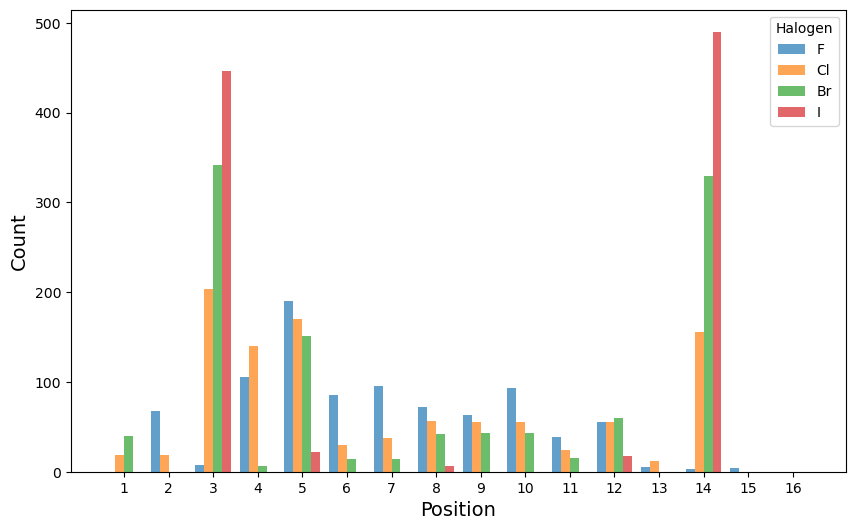

In [18]:
# Count the occurrences of each halogen at each position
halogen_counts = {halogen: [0] * len(positions) for halogen in halogens}
for molecule, _ in good_candidates:  # Unpack the tuple
    for pos, atom in enumerate(molecule):
        if atom in halogens:
            halogen_counts[atom][pos] += 1

# Plot the results
plt.figure(figsize=(10, 6))
bar_width = 0.2
offsets = [-1.5 * bar_width, -0.5 * bar_width, 0.5 * bar_width, 1.5 * bar_width]  # For 4 halogens

for i, (halogen, counts) in enumerate(halogen_counts.items()):
    plt.bar(
        [pos + offsets[i] for pos in range(len(positions))],
        counts,
        width=bar_width,
        label=halogen,
        alpha=0.7
    )

plt.xlabel("Position", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(range(len(positions)), [str(p) for p in positions])
plt.legend(title="Halogen")
plt.grid(False)
plt.show()

# ΔR_min by Position for Tetrahalogenated [6]Helicene (vs Trihalogenated)

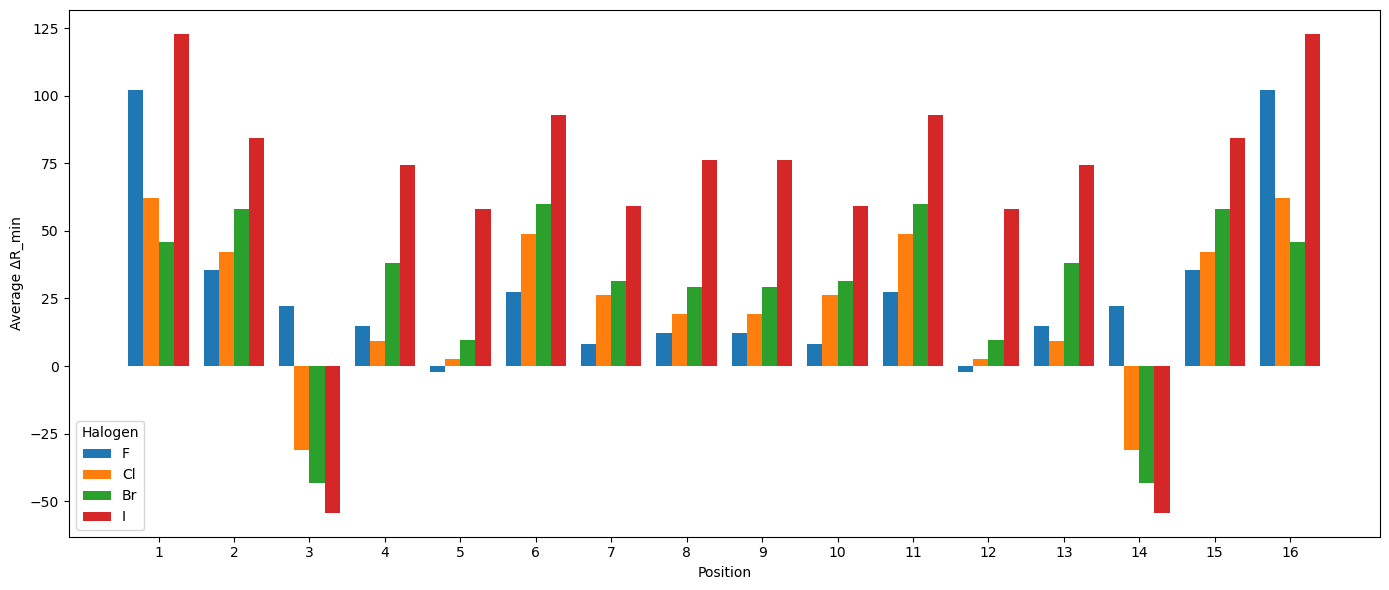

In [19]:
# Step 0: Prepare prediction dictionaries
tetra_rmin = {tuple(molecule): rmin for molecule, rmin in tetra_predictions}

# Initialize accumulators
delta_rmin_tetrahalogenated = {hal: [0.0] * 16 for hal in halogens}
count_deltas = {hal: [0] * 16 for hal in halogens}

# Step 1: Accumulate ΔRmin by comparing tetra- vs tri-halogenated molecules
for molecule, rmin_tetra in tetra_rmin.items():
    halogens_in_molecule = [(pos, atom) for pos, atom in enumerate(molecule) if atom in halogens]
    if len(halogens_in_molecule) != 4:
        continue

    # Generate each tri-halogenated version (remove one halogen at a time)
    for idx in range(4):
        pos_removed, hal_removed = halogens_in_molecule[idx]
        tri_molecule = list(molecule)
        tri_molecule[pos_removed] = 'H'

        rmin_tri = tri_rmin.get(tuple(tri_molecule), None)
        if rmin_tri is None:
            continue

        delta = rmin_tetra - rmin_tri
        delta_rmin_tetrahalogenated[hal_removed][pos_removed] += delta
        count_deltas[hal_removed][pos_removed] += 1

# Step 2: Enforce symmetry by mirror-averaging
for hal in halogens:
    for i in range(8):
        j = 15 - i  # Mirror position
        total_delta = delta_rmin_tetrahalogenated[hal][i] + delta_rmin_tetrahalogenated[hal][j]
        total_count = count_deltas[hal][i] + count_deltas[hal][j]
        avg = total_delta / total_count if total_count > 0 else 0.0
        delta_rmin_tetrahalogenated[hal][i] = avg
        delta_rmin_tetrahalogenated[hal][j] = avg

# Step 3: Plotting
positions_array = np.arange(16)
bar_width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(14, 6))

for i, hal in enumerate(halogens):
    pos_shifted = positions_array + offsets[i] * bar_width
    ax.bar(pos_shifted, delta_rmin_tetrahalogenated[hal], width=bar_width, label=hal)

ax.set_xticks(positions_array)
ax.set_xticklabels(positions_array + 1)
ax.set_xlabel('Position')
ax.set_ylabel('Average ΔR_min')
ax.legend(title='Halogen')
plt.tight_layout()
plt.show()


# Data analysis for penta-halogenated [6]Helicenes

# Prediction of the TOP 10 using encode_batch
Now we have 2236416 molecules. So we can use a batch to make it faster without loosing generalization.

In [20]:
BATCH_SIZE = 4096
penta_predictions = predict_rmin_substituted(
    n_subs=5,
    model=best_model,
    mean=Rmin_abs_mean,
    std=Rmin_abs_std
)
#Mean Rmin value
mean_rmin = np.mean([pred[1] for pred in penta_predictions])
print(f"Mean Rmin value for all penta-halogenated molecules: {mean_rmin:.2f}")


 Predicting 5-halogenated molecules...
Batch 0: processed 4096 molecules
Batch 10: processed 45056 molecules
Batch 20: processed 86016 molecules
Batch 30: processed 126976 molecules
Batch 40: processed 167936 molecules
Batch 50: processed 208896 molecules
Batch 60: processed 249856 molecules
Batch 70: processed 290816 molecules
Batch 80: processed 331776 molecules
Batch 90: processed 372736 molecules
Batch 100: processed 413696 molecules
Batch 110: processed 454656 molecules
Batch 120: processed 495616 molecules
Batch 130: processed 536576 molecules
Batch 140: processed 577536 molecules
Batch 150: processed 618496 molecules
Batch 160: processed 659456 molecules
Batch 170: processed 700416 molecules
Batch 180: processed 741376 molecules
Batch 190: processed 782336 molecules
Batch 200: processed 823296 molecules
Batch 210: processed 864256 molecules
Batch 220: processed 905216 molecules
Batch 230: processed 946176 molecules
Batch 240: processed 987136 molecules
Batch 250: processed 1028

# Predictions with Rmin Lower than -650

In [21]:
'''# Filter penta_predictions for Rmax <= -650
good_candidates = [(mol, rmin) for mol, rmin in penta_predictions if rmin <= -650]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)

print(f"\nTotal molecules with Rmin <= -650: {len(good_candidates)}")'''

# Filter top 1000 penta_predictions
good_candidates = penta_predictions[:1000]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)

# Location of Halogens in Pentahalogenated [6]Helicenes

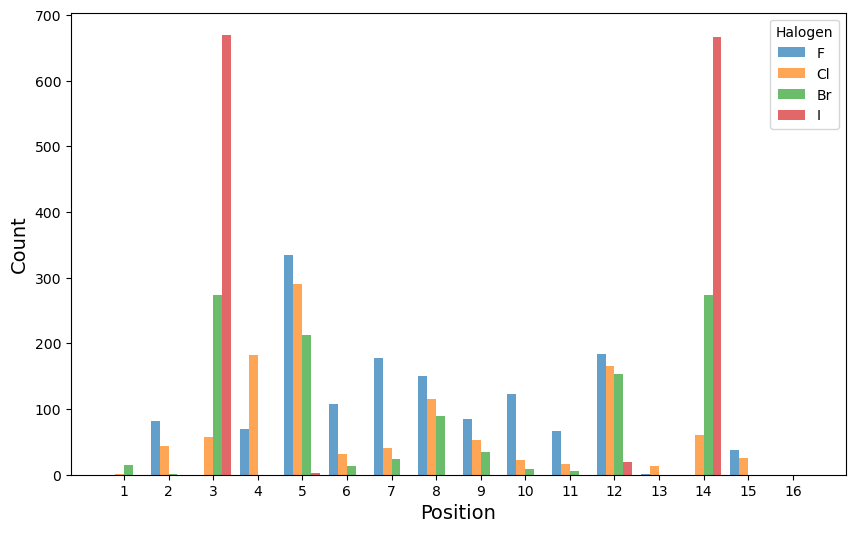

In [22]:
# Count the occurrences of each halogen at each position
halogen_counts = {halogen: [0] * len(positions) for halogen in halogens}
for molecule, _ in good_candidates:  # Unpack the tuple
    for pos, atom in enumerate(molecule):
        if atom in halogens:
            halogen_counts[atom][pos] += 1

# Plot the results
plt.figure(figsize=(10, 6))
bar_width = 0.2
offsets = [-1.5 * bar_width, -0.5 * bar_width, 0.5 * bar_width, 1.5 * bar_width]  # For 4 halogens

for i, (halogen, counts) in enumerate(halogen_counts.items()):
    plt.bar(
        [pos + offsets[i] for pos in range(len(positions))],
        counts,
        width=bar_width,
        label=halogen,
        alpha=0.7
    )

plt.xlabel("Position", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(range(len(positions)), [str(p) for p in positions])
plt.legend(title="Halogen")
plt.grid(False)
plt.show()

# ΔR_min by position for Pentahalogenated [6]Helicene (vs Tetrahalogenated)

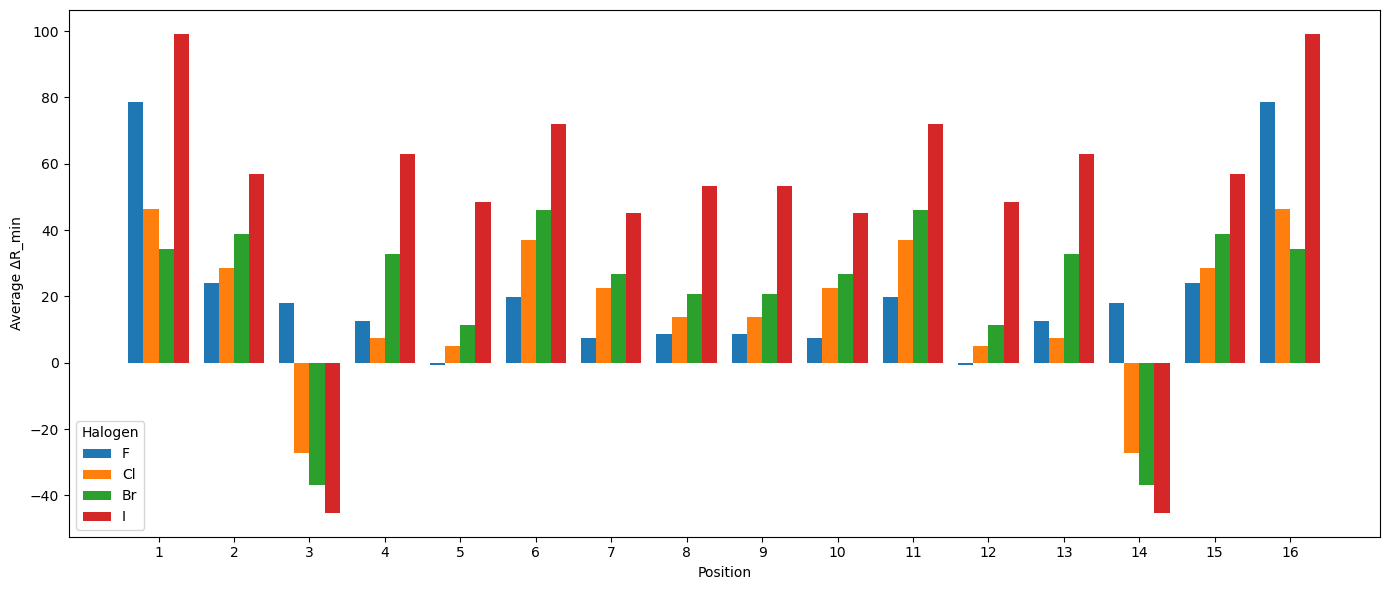

In [23]:
# Step 0: Prepare prediction dictionaries
penta_rmin = {tuple(molecule): rmin for molecule, rmin in penta_predictions}

# Initialize accumulators
delta_rmin_pentahalogenated = {hal: [0.0] * 16 for hal in halogens}
count_deltas = {hal: [0] * 16 for hal in halogens}

# Step 1: Accumulate ΔRmin by comparing penta- vs tetra-halogenated molecules
for molecule, rmin_penta in penta_rmin.items():
    halogens_in_molecule = [(pos, atom) for pos, atom in enumerate(molecule) if atom in halogens]
    if len(halogens_in_molecule) != 5:
        continue

    # Generate each penta-halogenated version (remove one halogen at a time)
    for idx in range(5):
        pos_removed, hal_removed = halogens_in_molecule[idx]
        tetra_molecule = list(molecule)
        tetra_molecule[pos_removed] = 'H'

        rmin_tetra = tetra_rmin.get(tuple(tetra_molecule), None)
        if rmin_tetra is None:
            continue

        delta = rmin_penta - rmin_tetra
        delta_rmin_pentahalogenated[hal_removed][pos_removed] += delta
        count_deltas[hal_removed][pos_removed] += 1

# Step 2: Enforce symmetry by mirror-averaging
for hal in halogens:
    for i in range(8):
        j = 15 - i  # Mirror position
        total_delta = delta_rmin_pentahalogenated[hal][i] + delta_rmin_pentahalogenated[hal][j]
        total_count = count_deltas[hal][i] + count_deltas[hal][j]
        avg = total_delta / total_count if total_count > 0 else 0.0
        delta_rmin_pentahalogenated[hal][i] = avg
        delta_rmin_pentahalogenated[hal][j] = avg

# Step 3: Plotting
positions_array = np.arange(16)
bar_width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(14, 6))

for i, hal in enumerate(halogens):
    pos_shifted = positions_array + offsets[i] * bar_width
    ax.bar(pos_shifted, delta_rmin_pentahalogenated[hal], width=bar_width, label=hal)

ax.set_xticks(positions_array)
ax.set_xticklabels(positions_array + 1)
ax.set_xlabel('Position')
ax.set_ylabel('Average ΔR_min')
ax.legend(title='Halogen')
plt.tight_layout()
plt.show()


# Data analysis for hexa-halogenated [6]Helicenes

# Prediction of the TOP 10 using encode_batch
Now we have 16402176 molecules. So we can use a batch to make it faster without loosing generalization.

In [24]:
BATCH_SIZE=4096

hexa_predictions = predict_rmin_substituted(
    n_subs=6,
    model=best_model,
    mean=Rmin_abs_mean,
    std=Rmin_abs_std
)
# Mean Rmin value
mean_rmin = np.mean([pred[1] for pred in hexa_predictions])
print(f"Mean Rmin value for all hexa-halogenated molecules: {mean_rmin:.2f}")


 Predicting 6-halogenated molecules...
Batch 0: processed 4096 molecules
Batch 10: processed 45056 molecules
Batch 20: processed 86016 molecules
Batch 30: processed 126976 molecules
Batch 40: processed 167936 molecules
Batch 50: processed 208896 molecules
Batch 60: processed 249856 molecules
Batch 70: processed 290816 molecules
Batch 80: processed 331776 molecules
Batch 90: processed 372736 molecules
Batch 100: processed 413696 molecules
Batch 110: processed 454656 molecules
Batch 120: processed 495616 molecules
Batch 130: processed 536576 molecules
Batch 140: processed 577536 molecules
Batch 150: processed 618496 molecules
Batch 160: processed 659456 molecules
Batch 170: processed 700416 molecules
Batch 180: processed 741376 molecules
Batch 190: processed 782336 molecules
Batch 200: processed 823296 molecules
Batch 210: processed 864256 molecules
Batch 220: processed 905216 molecules
Batch 230: processed 946176 molecules
Batch 240: processed 987136 molecules
Batch 250: processed 1028

# Predictions with Rmin Lower than -650

In [25]:
'''# Filter tetra_predictions for Rmin <= -650
good_candidates = [(mol, rmin) for mol, rmin in penta_predictions if rmin <= -650]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)

print(f"\nTotal molecules with Rmin <= -650: {len(good_candidates)}")'''

# Filter top 1000 hexa_predictions
good_candidates = hexa_predictions[:1000]

# Sort results
good_candidates.sort(key=lambda x: x[1], reverse=False)

# Location of Halogens in Hexahalogenated [6]Helicenes

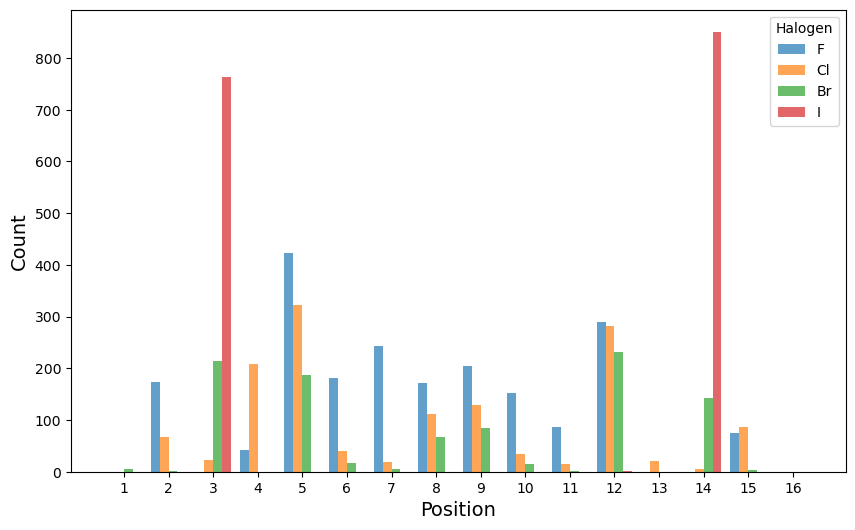

In [27]:
# Count the occurrences of each halogen at each position
halogen_counts = {halogen: [0] * len(positions) for halogen in halogens}
for molecule, _ in good_candidates:  # Unpack the tuple
    for pos, atom in enumerate(molecule):
        if atom in halogens:
            halogen_counts[atom][pos] += 1

# Plot the results
plt.figure(figsize=(10, 6))
bar_width = 0.2
offsets = [-1.5 * bar_width, -0.5 * bar_width, 0.5 * bar_width, 1.5 * bar_width]  # For 4 halogens

for i, (halogen, counts) in enumerate(halogen_counts.items()):
    plt.bar(
        [pos + offsets[i] for pos in range(len(positions))],
        counts,
        width=bar_width,
        label=halogen,
        alpha=0.7
    )

plt.xlabel("Position", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(range(len(positions)), [str(p) for p in positions])
plt.legend(title="Halogen")
plt.grid(False)
plt.show()

# ΔR_min by Position for Hexahalogenated [6]Helicene (vs Pentahalogenated)

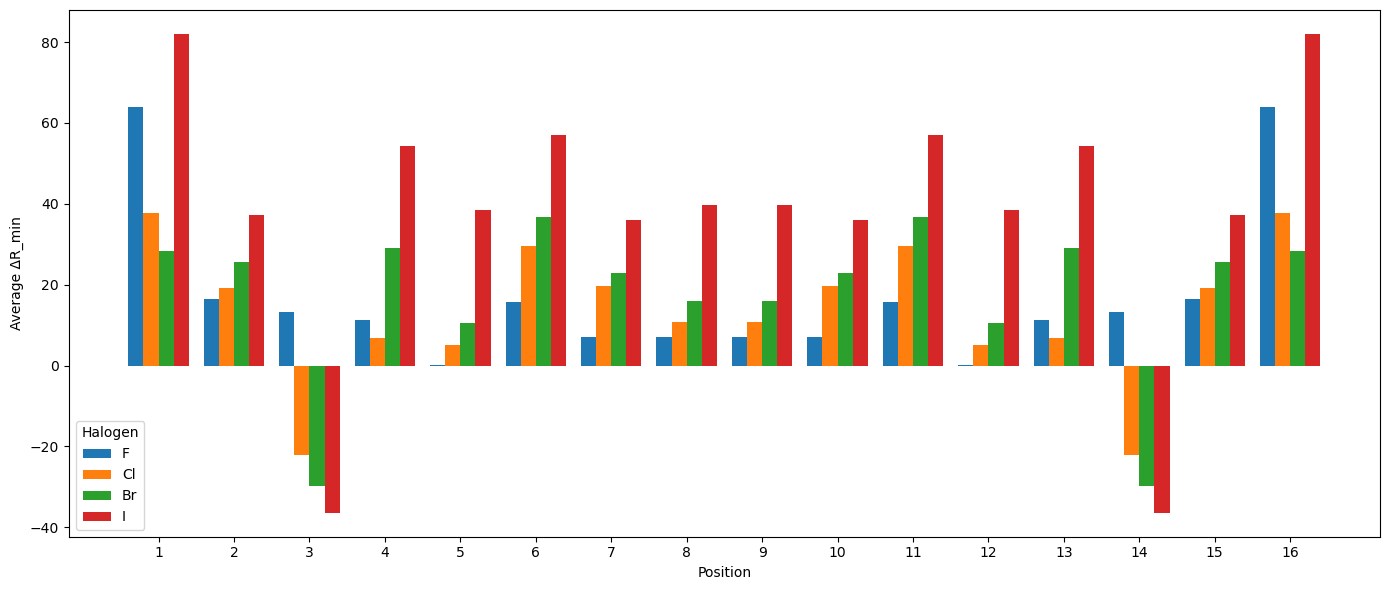

In [27]:
# Step 0: Prepare prediction dictionaries
hexa_rmin = {tuple(molecule): rmin for molecule, rmin in hexa_predictions}

# Initialize accumulators
delta_rmin_hexahalogenated = {hal: [0.0] * 16 for hal in halogens}
count_deltas = {hal: [0] * 16 for hal in halogens}

# Step 1: Accumulate ΔRmin by comparing penta- vs tetra-halogenated molecules
for molecule, rmin_hexa in hexa_rmin.items():
    halogens_in_molecule = [(pos, atom) for pos, atom in enumerate(molecule) if atom in halogens]
    if len(halogens_in_molecule) != 6:
        continue

    # Generate each hexa-halogenated version (remove one halogen at a time)
    for idx in range(6):
        pos_removed, hal_removed = halogens_in_molecule[idx]
        penta_molecule = list(molecule)
        penta_molecule[pos_removed] = 'H'

        rmin_penta = penta_rmin.get(tuple(penta_molecule), None)
        if rmin_penta is None:
            continue

        delta = rmin_hexa - rmin_penta
        delta_rmin_hexahalogenated[hal_removed][pos_removed] += delta
        count_deltas[hal_removed][pos_removed] += 1

# Step 2: Enforce symmetry by mirror-averaging
for hal in halogens:
    for i in range(8):
        j = 15 - i  # Mirror position
        total_delta = delta_rmin_hexahalogenated[hal][i] + delta_rmin_hexahalogenated[hal][j]
        total_count = count_deltas[hal][i] + count_deltas[hal][j]
        avg = total_delta / total_count if total_count > 0 else 0.0
        delta_rmin_hexahalogenated[hal][i] = avg
        delta_rmin_hexahalogenated[hal][j] = avg

# Step 3: Plotting
positions_array = np.arange(16)
bar_width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(14, 6))

for i, hal in enumerate(halogens):
    pos_shifted = positions_array + offsets[i] * bar_width
    ax.bar(pos_shifted, delta_rmin_hexahalogenated[hal], width=bar_width, label=hal)

ax.set_xticks(positions_array)
ax.set_xticklabels(positions_array + 1)
ax.set_xlabel('Position')
ax.set_ylabel('Average ΔR_min')
ax.legend(title='Halogen')
plt.tight_layout()
plt.show()


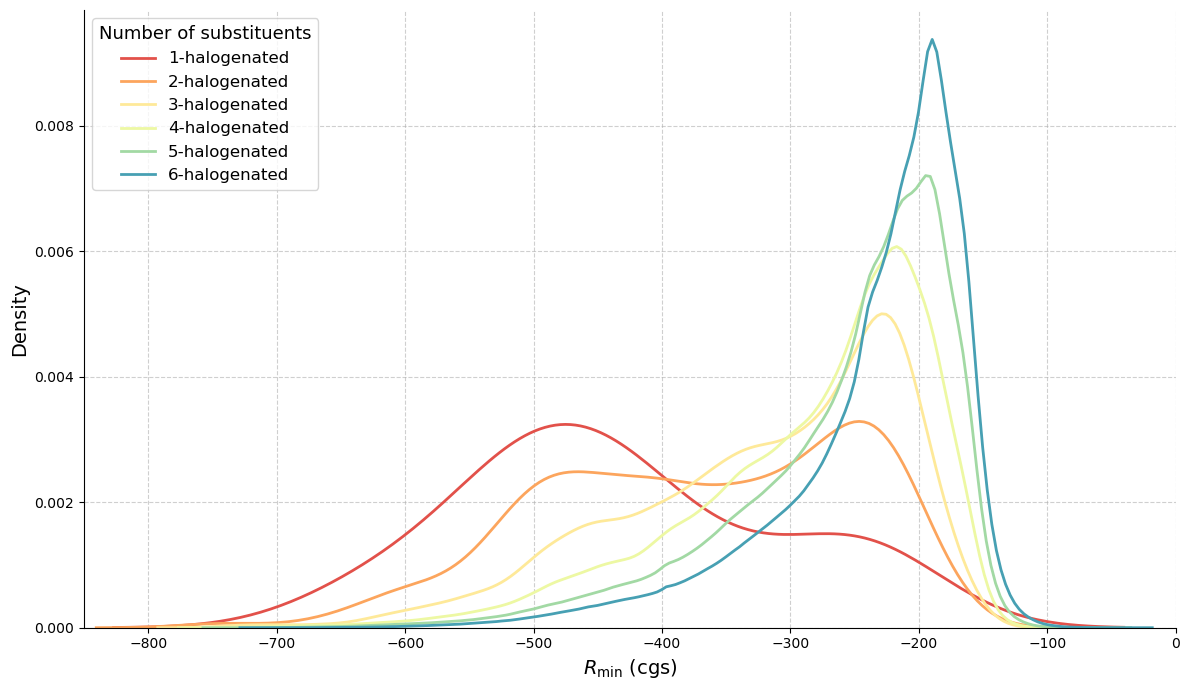

In [28]:
import seaborn as sns

def plot_all_rmin_distributions(predictions_list, labels, bw_method='scott'):
    plt.figure(figsize=(12, 7))
    colors = sns.color_palette("Spectral", len(predictions_list))

    for preds, label, c in zip(predictions_list, labels, colors):
        rmax_vals = [r for _, r in preds]
        sns.kdeplot(
            rmax_vals,
            bw_method=bw_method,
            fill=False,
            linewidth=2,
            label=label,
            color=c,
            common_norm=False  # Marginal normalization for each distribution
        )

    plt.xlabel('$R_{\\min}$ (cgs)', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.xlim(-850, 0)
    plt.grid(linestyle='--', alpha=0.6)
    plt.legend(title='Number of substituents', fontsize=12, title_fontsize=13, loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()

# Preparas tus datos y etiquetas
preds = [
    mono_predictions,
    di_predictions,
    tri_predictions,
    tetra_predictions,
    penta_predictions,
    hexa_predictions
]
labels = [f'{n}-halogenated' for n in range(1, 7)]

# Llamada a la función
plot_all_rmin_distributions(preds, labels)


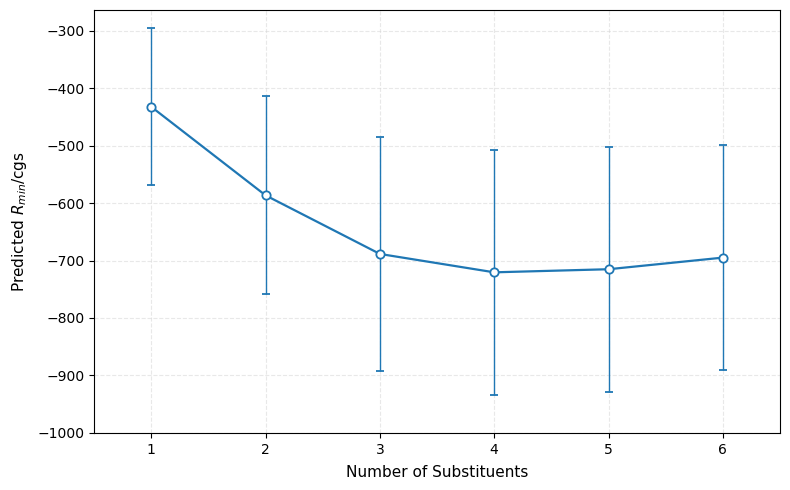

In [35]:
# 1) Compute mean_rmin and full_widths for n = 1..6
mean_rmax   = []
full_widths = []
labels      = list(range(1, 17))
index_to_halogen = {0: 'H', 1: 'F', 2: 'Cl', 3: 'Br', 4: 'I'}

for n_subs, preds in zip(
    range(1, 7),
    [mono_predictions, di_predictions, tri_predictions, tetra_predictions, penta_predictions, hexa_predictions]
):
    top_preds = sorted(preds, key=lambda x: x[1], reverse=False)[:100]
    rmax_vals = [r for (_, r) in top_preds]
    mean_val  = np.mean(rmax_vals)

    molecules   = [mol for (mol, _) in top_preds]
    encoded_6     = encode_batch(molecules)
    lower_real  = (model_lower.predict(encoded_6, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)
    upper_real  = (model_upper.predict(encoded_6, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)

    width = np.mean(upper_real - lower_real)

    mean_rmax  .append(mean_val)
    full_widths.append(width)

# 2) Plotting:
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['font.size']      = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')  # Set figure background to white
ax.set_facecolor('white')  # Set axes background to white

# Plot n = 1..6 with circle markers (solid) + error bars
ax.errorbar(
    labels[:6],
    mean_rmax[:6],
    yerr=np.array(full_widths[:6]) * 0.5,
    fmt='o-',
    color='tab:blue',
    ecolor='tab:blue',
    elinewidth=1.0,
    capsize=3,
    markerfacecolor='white',
    markeredgewidth=1.3,
    markersize=6,
    linewidth=1.6,
    label='_nolegend_'
)

# Axis labels and title
ax.set_xlabel('Number of Substituents', fontsize=11, labelpad=6)
ax.set_ylabel(r'Predicted $R_{min}$/cgs', fontsize=11, labelpad=6)

# Ticks and grid
ax.set_xticks(labels)
ax.set_xticklabels(labels)
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(0.5, 6.5)
ax.set_ylim(bottom=-1000)
ax.grid(linestyle='--', alpha=0.5, color='lightgray')

# Ensure all spines (borders) are visible and styled
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()


# Data analysis for hepta to hexadeca-halogenated [6]Helicenes


# Rmin Mean Values per nsubs with uncertainty
In this caes we use predictions without penalization for 7 to 16 substituents

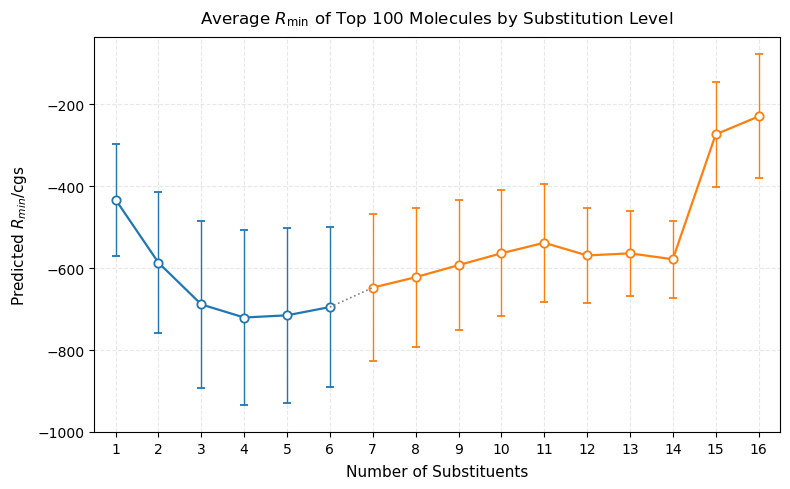

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load the GA‐derived CSV for n = 7…16
df_top100 = pd.read_csv('ga_top100_Rmin_n7_16.csv')

# 2) Compute mean_rmin and full_widths for n = 1..16
mean_rmin   = []
full_widths = []
labels      = list(range(1, 17))
index_to_halogen = {0: 'H', 1: 'F', 2: 'Cl', 3: 'Br', 4: 'I'}
# 2A) n = 1..6 (brute‐force lists)
for n_subs, preds in zip(
    range(1, 7),
    [mono_predictions, di_predictions, tri_predictions, tetra_predictions, penta_predictions, hexa_predictions]
):
    # sort in ascending order to pick the 100 smallest R values
    top_preds = sorted(preds, key=lambda x: x[1], reverse = False)[:100]
    rmin_vals = [r for (_, r) in top_preds]
    mean_val  = np.mean(rmin_vals)

    molecules = [mol for (mol, _) in top_preds]
    encoded_6 = encode_batch(molecules)
    lower_real = (model_lower.predict(encoded_6, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)
    upper_real = (model_upper.predict(encoded_6, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)

    width = np.mean(upper_real - lower_real)

    mean_rmin.append(mean_val)
    full_widths.append(width)

# 2B) n = 7..16 (GA‐derived)
for n_subs in range(7, 17):
    df_n       = df_top100[df_top100['n_subs'] == n_subs]
    mu_real    = df_n['mu_real'].values
    sigma_real = df_n['sigma_real'].values

     # Convert genotype strings to lists of atom labels
    molecules = []
    for geno_str in df_n['genotype']:
        indices = [int(x) for x in geno_str.split('-')]
        atoms = [index_to_halogen[i] for i in indices]
        molecules.append(atoms)

    encoded_16  = encode_batch(molecules)
    lower_real  = (model_lower.predict(encoded_16, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)
    upper_real  = (model_upper.predict(encoded_16, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)

    mean_val = mu_real.mean()
    width    = 2.0 * sigma_real.mean()

    mean_rmin.append(mean_val)
    full_widths.append(width)

# 3) Plotting:
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['font.size']      = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

# b) Plot n = 1..6 with circle markers (solid) + error bars
ax.errorbar(
    labels[:6],
    mean_rmin[:6],
    yerr=np.array(full_widths[:6]) * 0.5,
    fmt='o-',
    color='tab:blue',
    ecolor='tab:blue',
    elinewidth=1.0,
    capsize=3,
    markerfacecolor='white',
    markeredgewidth=1.3,
    markersize=6,
    linewidth=1.6,
    label='_nolegend_'
)

# c) Plot n = 7..16 with square markers (dashed) + error bars
ax.errorbar(
    labels[6:],
    mean_rmin[6:],
    yerr=np.array(full_widths[6:]) * 0.5,
    fmt='o-',
    color='tab:orange',
    ecolor='tab:orange',
    elinewidth=1.0,
    capsize=3,
    markerfacecolor='white',
    markeredgewidth=1.3,
    markersize=6,
    linewidth=1.6,
    label='_nolegend_'
)

# d) Dotted connector between n = 6 and n = 7
ax.plot(
    [6, 7],
    [mean_rmin[5], mean_rmin[6]],
    linestyle=':',
    color='gray',
    linewidth=1.2,
    zorder=3
)

# e) Axis labels and title (updated for R_min)
ax.set_xlabel('Number of Substituents', fontsize=11, labelpad=6)
ax.set_ylabel(r'Predicted $R_{min}$/cgs', fontsize=11, labelpad=6)
ax.set_title('Average $R_{\min}$ of Top 100 Molecules by Substitution Level', fontsize=12, pad=10)

# f) Ticks, grid, and updated y-limit
ax.set_xticks(labels)
ax.set_xticklabels(labels)
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(0.5, 16.5)
ax.set_ylim(bottom=-1000)
ax.grid(linestyle='--', alpha=0.5, color='lightgray')

# g) Ensure all spines are visible and styled
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()


# Rmin Mean Values per nsubs with uncertainty
In this case we use predictions with penalization for 7 to 16 substituents

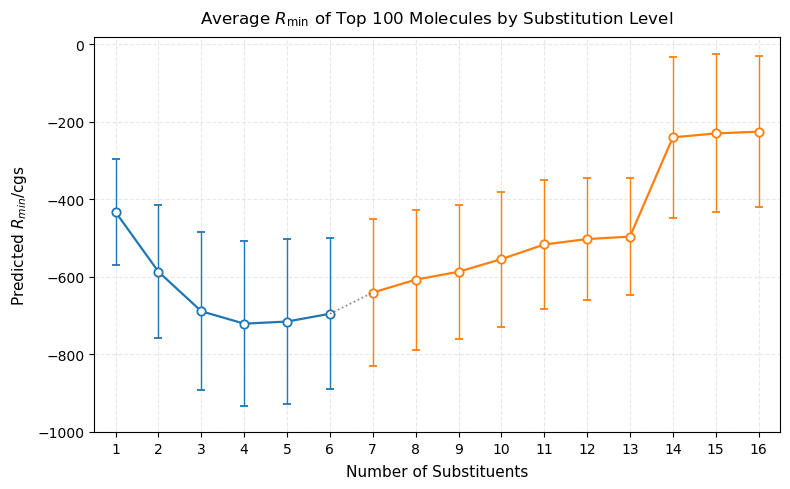

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load the GA‐derived CSV for n = 7…16
df_top100 = pd.read_csv('ga_top100_Rmin_n7_16_penal.csv')

# 2) Compute mean_rmin and full_widths for n = 1..16
mean_rmin   = []
full_widths = []
labels      = list(range(1, 17))
index_to_halogen = {0: 'H', 1: 'F', 2: 'Cl', 3: 'Br', 4: 'I'}
# 2A) n = 1..6 (brute‐force lists)
for n_subs, preds in zip(
    range(1, 7),
    [mono_predictions, di_predictions, tri_predictions, tetra_predictions, penta_predictions, hexa_predictions]
):
    # sort in ascending order to pick the 100 smallest R values
    top_preds = sorted(preds, key=lambda x: x[1], reverse = False)[:100]
    rmin_vals = [r for (_, r) in top_preds]
    mean_val  = np.mean(rmin_vals)

    molecules = [mol for (mol, _) in top_preds]
    encoded_6 = encode_batch(molecules)
    lower_real = (model_lower.predict(encoded_6, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)
    upper_real = (model_upper.predict(encoded_6, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)

    width = np.mean(upper_real - lower_real)

    mean_rmin.append(mean_val)
    full_widths.append(width)

# 2B) n = 7..16 (GA‐derived)
for n_subs in range(7, 17):
    df_n       = df_top100[df_top100['n_subs'] == n_subs]
    mu_real    = df_n['mu_real'].values
    sigma_real = df_n['sigma_real'].values

     # Convert genotype strings to lists of atom labels
    molecules = []
    for geno_str in df_n['genotype']:
        indices = [int(x) for x in geno_str.split('-')]
        atoms = [index_to_halogen[i] for i in indices]
        molecules.append(atoms)

    encoded_16  = encode_batch(molecules)
    lower_real  = (model_lower.predict(encoded_16, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)
    upper_real  = (model_upper.predict(encoded_16, verbose=0).ravel() * Rmin_abs_std + Rmin_abs_mean)

    mean_val = mu_real.mean()
    width    = 2.0 * sigma_real.mean()

    mean_rmin.append(mean_val)
    full_widths.append(width)

# 3) Plotting:
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['font.size']      = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

# b) Plot n = 1..6 with circle markers (solid) + error bars
ax.errorbar(
    labels[:6],
    mean_rmin[:6],
    yerr=np.array(full_widths[:6]) * 0.5,
    fmt='o-',
    color='tab:blue',
    ecolor='tab:blue',
    elinewidth=1.0,
    capsize=3,
    markerfacecolor='white',
    markeredgewidth=1.3,
    markersize=6,
    linewidth=1.6,
    label='_nolegend_'
)

# c) Plot n = 7..16 with square markers (dashed) + error bars
ax.errorbar(
    labels[6:],
    mean_rmin[6:],
    yerr=np.array(full_widths[6:]) * 0.5,
    fmt='o-',
    color='tab:orange',
    ecolor='tab:orange',
    elinewidth=1.0,
    capsize=3,
    markerfacecolor='white',
    markeredgewidth=1.3,
    markersize=6,
    linewidth=1.6,
    label='_nolegend_'
)

# d) Dotted connector between n = 6 and n = 7
ax.plot(
    [6, 7],
    [mean_rmin[5], mean_rmin[6]],
    linestyle=':',
    color='gray',
    linewidth=1.2,
    zorder=3
)

# e) Axis labels and title (updated for R_min)
ax.set_xlabel('Number of Substituents', fontsize=11, labelpad=6)
ax.set_ylabel(r'Predicted $R_{min}$/cgs', fontsize=11, labelpad=6)
ax.set_title('Average $R_{\min}$ of Top 100 Molecules by Substitution Level', fontsize=12, pad=10)

# f) Ticks, grid, and updated y-limit
ax.set_xticks(labels)
ax.set_xticklabels(labels)
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(0.5, 16.5)
ax.set_ylim(bottom=-1000)
ax.grid(linestyle='--', alpha=0.5, color='lightgray')

# g) Ensure all spines are visible and styled
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()


# Save top 10 molecules per nsubs

In [32]:
import csv

with open('top_10_molecules_per_substituent.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    for n_subs, preds in zip(
        range(1, 7),
        [mono_predictions, di_predictions, tri_predictions, tetra_predictions, penta_predictions, hexa_predictions]
    ):
        writer.writerow([f'--- Top 10 for n_subs = {n_subs} ---'])
        top_preds = sorted(preds, key=lambda x: x[1], reverse=False)[:10]
        for rank, (mol, rmin) in enumerate(top_preds, start=1):
            writer.writerow([f'Rank {rank}: Rmin = {rmin:.2f}'])
            writer.writerow([f'Molecule: {str(mol)}'])
            writer.writerow(['--------------------------------------------------'])
        writer.writerow([])  # Blank line between groups

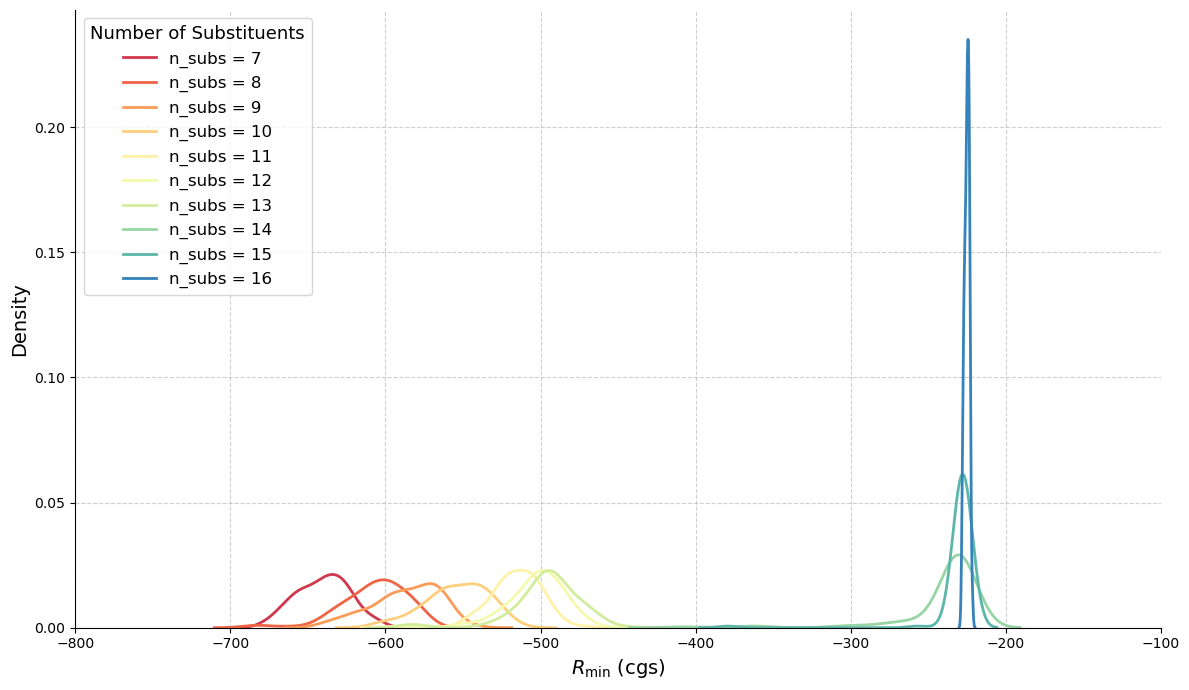

In [33]:
#KDE plot for Rmin distributions for 7 to 16
df_top100 = pd.read_csv('ga_top10000_Rmin_n7_16_penal.csv')
def plot_rmax_distributions(df, n_subs_range, bw_method='scott'):
    plt.figure(figsize=(12, 7))
    colors = sns.color_palette("Spectral", n_subs_range[1] - n_subs_range[0] + 1)

    for n_subs in range(n_subs_range[0], n_subs_range[1] + 1):
        subset = df[df['n_subs'] == n_subs]
        sns.kdeplot(
            subset['mu_real'],
            bw_method=bw_method,
            fill=False,
            linewidth=2,
            label=f'n_subs = {n_subs}',
            color=colors[n_subs - n_subs_range[0]],
            common_norm=False
        )

    plt.xlabel('$R_{\\min}$ (cgs)', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.xlim(-800, -100)
    plt.grid(linestyle='--', alpha=0.6)
    plt.legend(title='Number of Substituents', fontsize=12, title_fontsize=13, loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()
# Call the function to plot Rmax distributions for n_subs from 7 to 16
plot_rmax_distributions(df_top100, (7, 16), bw_method='scott')